# **Notebook 5: A deeper insight in model 2 and model 3b (probability distributions, attribution scores, and misclassifications)**

## 1. Importing the packages

In [1]:
! pip install transformers-interpret

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers_interpret import SequenceClassificationExplainer
from matplotlib.patches import Patch

## 2. Peparations

In [4]:
MODEL_DIR_M2   = "./Model 1: Finetuning with handlabeled data/model_1"
MODEL_DIR_M3   = "./Model 3: handlabeled + weak_labels/model_3_50"
TEST_DATA_PATH = "./Model 1: Finetuning with handlabeled data/labeled_test.csv"
PROB_DIR = "./Model 3: handlabeled + weak_labels/test_predictions"

PROBS_M2_PATH  = os.path.join(MODEL_DIR_M2, "test_probs.npy")
LABELS_M2_PATH = os.path.join(MODEL_DIR_M2, "test_labels.npy")
PROBS_M3_PATH  = os.path.join(PROB_DIR, "50%_test_probs.npy")
LABELS_M3_PATH = os.path.join(PROB_DIR, "50%_test_labels.npy")

MODEL_NAME = "pdelobelle/robbert-v2-dutch-base"
MAX_LENGTH = 100
LABEL_COL  = "unnecessary"
SENT_COL   = "blurb_sent"
T_M2       = 0.62
T_M3       = 0.63

## 3. Loading the predictions and needed data

In [5]:
# Loading test data
test_df = pd.read_csv(TEST_DATA_PATH)
print(f"Test: {len(test_df)} sentences")

# Loading predictions model 2
test_probs_m2 = np.load(PROBS_M2_PATH)
test_labels_m2 = np.load(LABELS_M2_PATH)
test_preds_m2 = (test_probs_m2 >= T_M2).astype(int)

# Loading predictions model 3b
test_probs_3b = np.load(PROBS_M3_PATH)
test_labels_3b = np.load(LABELS_M3_PATH)
test_preds_3b = (test_probs_3b >= T_M3).astype(int)

# Derived data
test_sentences = test_df[SENT_COL].tolist()


print("Predictions loaded")

Test: 481 sentences
Predictions loaded


## 4. Combined probability distribution plot

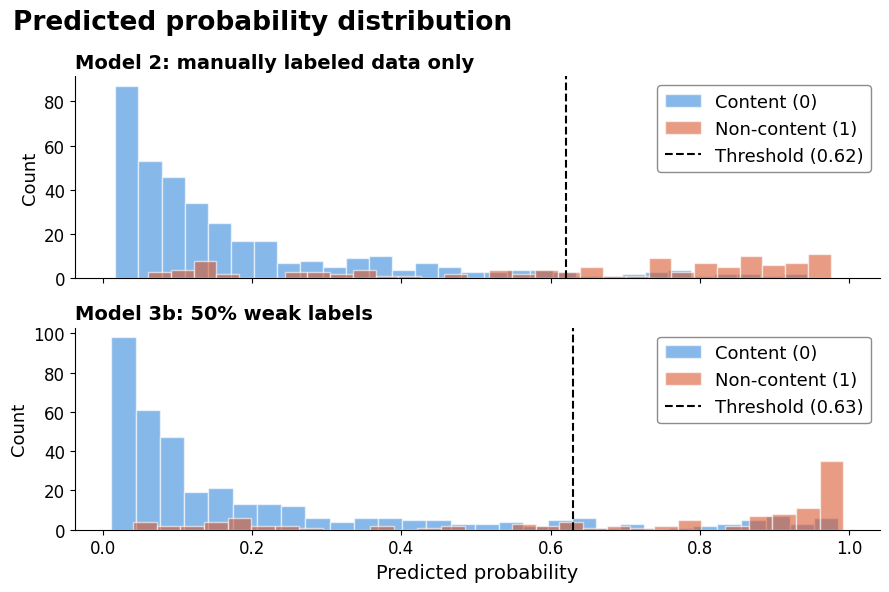

In [6]:
# Combined plots of distribution model 2 and 3b
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for ax, probs, labels, T, title in zip(
    axes,
    [test_probs_m2, test_probs_3b],
    [test_labels_m2, test_labels_3b],
    [T_M2, T_M3],
    ["Model 2: manually labeled data only", "Model 3b: 50% weak labels"]):
    ax.hist(probs[labels == 0], bins=30, alpha=0.6, label="Content (0)", color="#378ADD", edgecolor="white")
    ax.hist(probs[labels == 1], bins=30, alpha=0.6, label="Non-content (1)", color="#D85A30", edgecolor="white")
    ax.axvline(T, linestyle="--", color="black", linewidth=1.5, label=f"Threshold ({T})")
    ax.set_title(title, fontsize=14, fontweight="bold", loc="left")
    ax.set_ylabel("Count", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, facecolor="white", edgecolor="gray", framealpha=0.9, fontsize=13)

axes[1].set_xlabel("Predicted probability", fontsize=14)
fig.suptitle("Predicted probability distribution", fontsize=19, fontweight="bold", x=0.02, ha="left", y=0.98)
plt.tight_layout()
plt.show()

## 5. Word attribution

In [7]:
# Specifications
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR_M2)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
explainer = SequenceClassificationExplainer(model, tokenizer)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
# Explainer for model 2
explainer = SequenceClassificationExplainer(model, tokenizer)

# Select correctly classified non-content setences
non_content_correct = [
    (sent, label) for sent, label, pred
    in zip(test_sentences, test_labels_m2, test_preds_m2)
    if label == 1 and pred == 1]

# Select correctly classified content sentences
content_correct = [
    (sent, label) for sent, label, pred
    in zip(test_sentences, test_labels_m2, test_preds_m2)
    if label == 0 and pred == 0]

# Word importance non-content
non_content_word_scores = {}

for sent, _ in non_content_correct[:70]:
    try:
        attributions = explainer(sent[:512])
        for word, score in attributions:
            if word not in ["[CLS]", "[SEP]", "[PAD]"]:
                non_content_word_scores[word] = (
                    non_content_word_scores.get(word, []) + [score])
    except:
        continue

# Word importance content
content_word_scores = {}

for sent, _ in content_correct[:70]:
    try:
        attributions = explainer(sent[:512])
        for word, score in attributions:
            if word not in ["[CLS]", "[SEP]", "[PAD]"]:
                content_word_scores[word] = (
                    content_word_scores.get(word, []) + [score])
    except:
        continue


In [9]:
# Filter: only positive scores (model 2)
non_content_avg = {w: np.mean(s) for w, s in non_content_word_scores.items() if len(s) >= 2}
non_content_top = sorted(non_content_avg.items(), key=lambda x: x[1], reverse=True)[:10]

content_avg = {w: np.mean(s) for w, s in content_word_scores.items() if np.mean(s) > 0 and len(s) >= 2}
content_top = sorted(content_avg.items(), key=lambda x: x[1], reverse=True)[:10]

In [10]:
# Explainer for model 3b
explainer = SequenceClassificationExplainer(model, tokenizer)

# Select correctly classified non-content setences
non_content_correct3b = [
    (sent, label) for sent, label, pred
    in zip(test_sentences, test_labels_3b, test_preds_3b)
    if label == 1 and pred == 1]

# Select correctly classified content sentences
content_correct3b = [
    (sent, label) for sent, label, pred
    in zip(test_sentences, test_labels_3b, test_preds_3b)
    if label == 0 and pred == 0]

# Word importance non-content
non_content_word_scores3b = {}

for sent, _ in non_content_correct3b[:70]:
    try:
        attributions = explainer(sent[:512])
        for word, score in attributions:
            if word not in ["[CLS]", "[SEP]", "[PAD]"]:
                non_content_word_scores3b[word] = (
                    non_content_word_scores3b.get(word, []) + [score])
    except:
        continue

# Word importance content
content_word_scores3b = {}

for sent, _ in content_correct3b[:70]:
    try:
        attributions = explainer(sent[:512])
        for word, score in attributions:
            if word not in ["[CLS]", "[SEP]", "[PAD]"]:
                content_word_scores3b[word] = (
                    content_word_scores3b.get(word, []) + [score])
    except:
        continue

In [11]:
# Filter: only positive scores (model 3b)
non_content_avg3b = {w: np.mean(s) for w, s in non_content_word_scores3b.items() if len(s) >= 2}
non_content_top3b = sorted(non_content_avg.items(), key=lambda x: x[1], reverse=True)[:10]

content_avg3b = {w: np.mean(s) for w, s in content_word_scores3b.items() if np.mean(s) > 0 and len(s) >= 2}
content_top3b = sorted(content_avg.items(), key=lambda x: x[1], reverse=True)[:10]

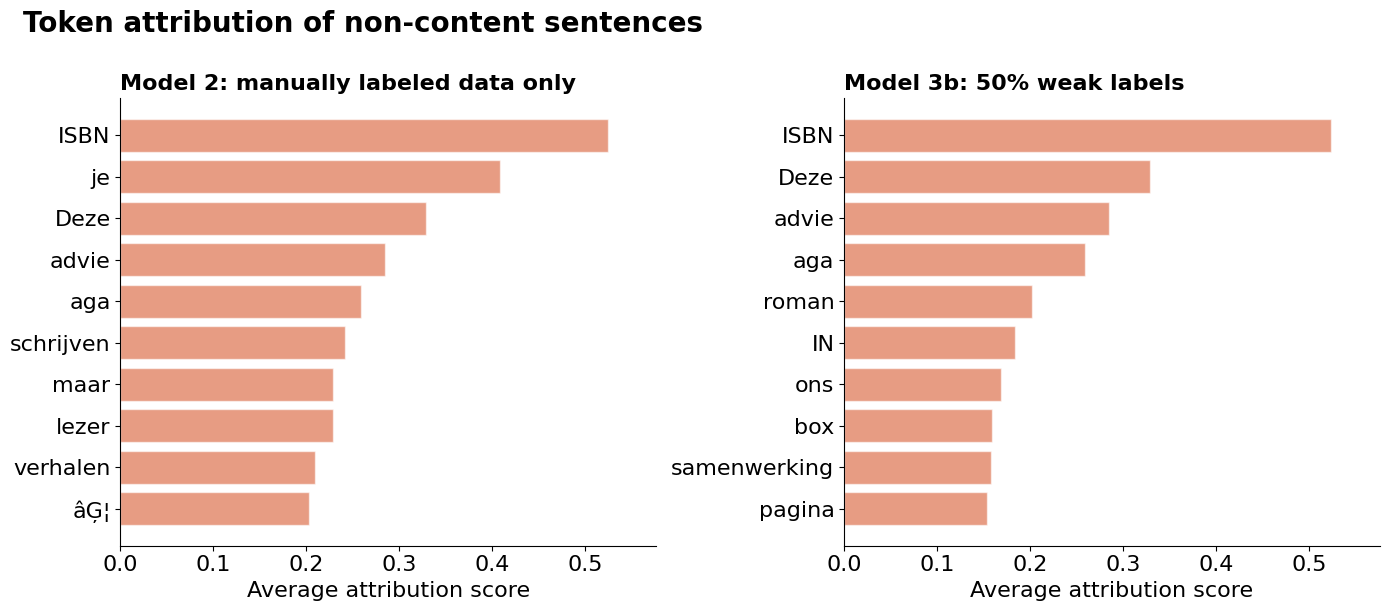

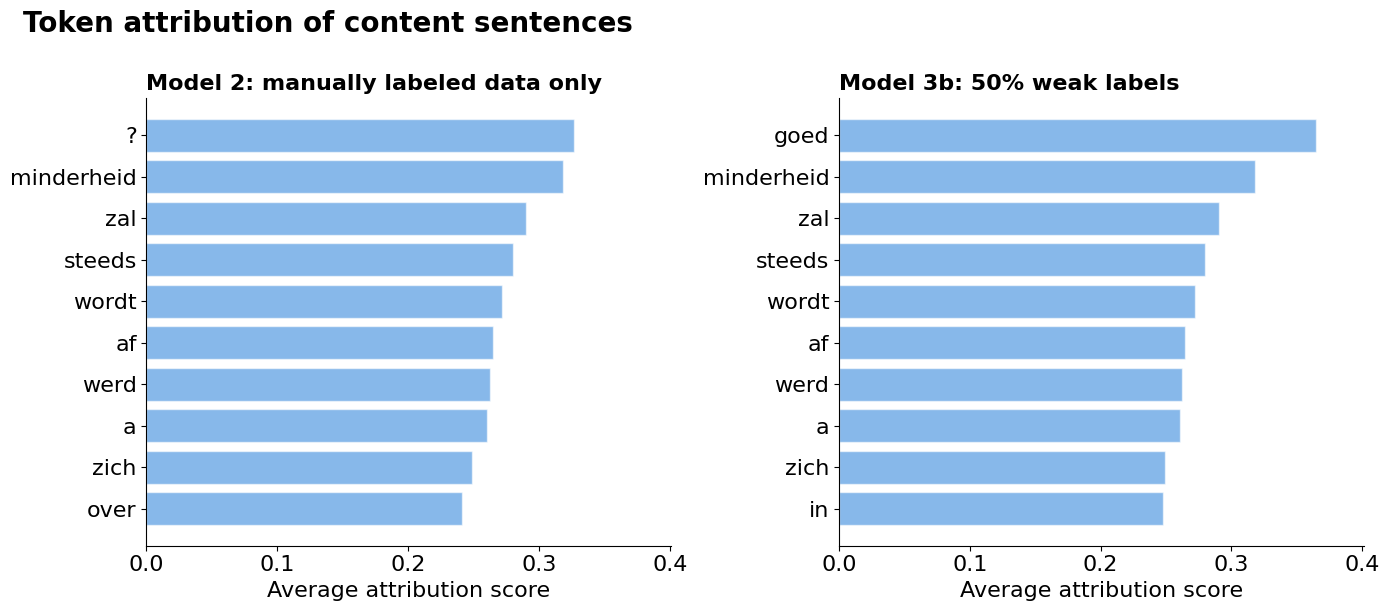

In [12]:
# Get top words per model per class

def get_top(score_dict, n=10):
    filtered = {w: s for w, s in score_dict.items()
                if w not in ["[CLS]", "[SEP]", "[PAD]"]}
    return sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:n]

nc_m2 = get_top(non_content_avg)
c_m2  = get_top(content_avg)
nc_m3 = get_top(non_content_avg3b)
c_m3  = get_top(content_avg3b)

# Figure 1: Non-content sentences
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
nc_configs = [
    (axes1[0], nc_m2, "#D85A30", "Model 2: manually labeled data only"),
    (axes1[1], nc_m3, "#D85A30", "Model 3b: 50% weak labels"),
]
all_nc_scores = [s for _, top, _, _ in nc_configs for _, s in top]
xmax_nc = max(all_nc_scores) * 1.1
for ax, top, color, model_title in nc_configs:
    words, scores = zip(*top)
    ax.barh(words, scores, color=color, alpha=0.6, edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Average attribution score", fontsize=16)
    ax.set_xlim(0, xmax_nc)
    ax.tick_params(axis="both", labelsize=16)
    ax.set_title(model_title, fontsize=16, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig1.suptitle("Token attribution of non-content sentences", fontsize=20, fontweight="bold", x=0.02, ha="left", y=1.01)
plt.tight_layout()
plt.show()

# Figure 2: Content sentences
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
c_configs = [
    (axes2[0], c_m2,  "#378ADD", "Model 2: manually labeled data only"),
    (axes2[1], c_m3,  "#378ADD", "Model 3b: 50% weak labels"),
]
all_c_scores = [s for _, top, _, _ in c_configs for _, s in top]
xmax_c = max(all_c_scores) * 1.1

for ax, top, color, model_title in c_configs:
    words, scores = zip(*top)
    ax.barh(words, scores, color=color, alpha=0.6, edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Average attribution score", fontsize=16)
    ax.set_xlim(0, xmax_c)
    ax.tick_params(axis="both", labelsize=16)
    ax.set_title(model_title, fontsize=16, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig2.suptitle("Token attribution of content sentences", fontsize=20, fontweight="bold", x=0.02, ha="left", y=1.01)
plt.tight_layout()
plt.show()

**Note:** The plot shown above was re-generated during code cleaning and differs from the figure in the thesis report. When run in a different environment, results may vary due to non-deterministic GPU behavior during Integrated Gradients computation. This also reflects the broader interpretive limitation noted in the thesis: attribution scores are illustrative rather than definitive.

## 6. Incorrectly classified sentences

In [13]:
# Model 2
print("\n=== False negatives (content → non-content) ===")
fn = [(sent, prob) for sent, label, pred, prob
      in zip(test_sentences, test_labels_m2, test_preds_m2, test_probs_m2)
      if label == 0 and pred == 1]
fn_sorted = sorted(fn, key=lambda x: x[1], reverse=True)
for sent, prob in fn_sorted[:10]:
    print(f"Prob: {prob:.3f} | {sent}")

print("\n=== False positives (non-content → content) ===")
fp = [(sent, prob) for sent, label, pred, prob
      in zip(test_sentences, test_labels_m2, test_preds_m2, test_probs_m2)
      if label == 1 and pred == 0]
fp_sorted = sorted(fp, key=lambda x: x[1])
for sent, prob in fp_sorted[:10]:
    print(f"Prob: {prob:.3f} | {sent}")

#------------------------------------------------------------------------------------------
# Output deactivated for data privacy concerns


=== False negatives (content → non-content) ===
Prob: 0.943 | “Lisette’s letterconfetti”, tweede humoristische verhalenbundel van Brabantse schrijfster.
Prob: 0.933 | De infrastructuur ook.
Prob: 0.883 | Dit boek is daarvan het resultaat.
Prob: 0.862 | Zoveel zielen.
Prob: 0.861 | Toch?
Prob: 0.844 | Meersburg, 1917.
Prob: 0.820 | Alles moet nog gebeuren.
Prob: 0.804 | Hij hanteert daarvoor als referentiekader de Transactionele analyse.
Prob: 0.786 | Dus geniet gewoon van de wijze, geestige en hilarische grappen in deze leuke leeftijdscadeauboeken.
Prob: 0.786 | Staatsrecht begrepen is een gestructureerde en systematische inleiding in het Nederlandse staatsrecht.

=== False positives (non-content → content) ===
Prob: 0.060 | Vrienden, collega’s, kennissen en soms zelfs vreemden – eigenlijk iedereen die ons op de een of andere manier weet te vinden – vraagt om advies voor een onvergetelijke vakantie op Curaçao.
Prob: 0.085 | Het voelde altijd alsof we het zelf bedachten, maar terugkijk

In [14]:
# Model 3b
print("\n=== False negatives (content → non-content) ===")
fn2 = [(sent, prob) for sent, label, pred, prob
      in zip(test_sentences, test_labels_3b, test_preds_3b, test_probs_3b)
      if label == 0 and pred == 1]
fn_sorted2 = sorted(fn2, key=lambda x: x[1], reverse=True)
for sent, prob in fn_sorted2[:10]:
    print(f"Prob: {prob:.3f} | {sent}")

print("\n=== False positives (non-content → content) ===")
fp2 = [(sent, prob) for sent, label, pred, prob
      in zip(test_sentences, test_labels_3b, test_preds_3b, test_probs_3b)
      if label == 1 and pred == 0]
fp_sorted2 = sorted(fp2, key=lambda x: x[1])
for sent, prob in fp_sorted2[:10]:
    print(f"Prob: {prob:.3f} | {sent}")

#------------------------------------------------------------------------------------------
# Output deactivated for data privacy concerns


=== False negatives (content → non-content) ===
Prob: 0.986 | “Lisette’s letterconfetti”, tweede humoristische verhalenbundel van Brabantse schrijfster.
Prob: 0.984 | Meersburg, 1917.
Prob: 0.969 | Zoveel zielen.
Prob: 0.969 | sprankelend, romantisch, hartverwarmend EXTRA 2in1 Avontuurlijke ontmoeting Dit is wel het spannendste dat ooit in de bibliotheek is gebeurd!
Prob: 0.962 | Want de dief is nota bene de knappe Sullivan Waring, de meest gerespecteerde paardenfokker van Engeland!
Prob: 0.955 | Dit boek is daarvan het resultaat.
Prob: 0.933 | Voor iedereen vanaf 5 jaar.
Prob: 0.926 | Hij hanteert daarvoor als referentiekader de Transactionele analyse.
Prob: 0.924 | Het boek verschijnt op 13 november a.s. Ook de afgelopen jaren waren groots en meeslepend.
Prob: 0.918 | Op veler verzoek uitgebreid met drie weekmenu's.

=== False positives (non-content → content) ===
Prob: 0.040 | Ieder boek vertelt een pakkend verhaal over onderwerpen waarmee jongeren te maken kunnen krijgen.
Prob: 0.